In [1]:
import os, sys
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-xrsana")
import matplotlib.pyplot as plt
import warnings
from xrsana.math_functions import pearson7

In [2]:
PROJECT_ROOT = "/home/hushiqi/work/xrs_ana"
SCAN_NAME = "Ho"
DATA_PATH = os.path.join(PROJECT_ROOT, "ex_space", "analysis", "data", SCAN_NAME)
RESULT_PATH = os.path.join(PROJECT_ROOT, "ex_space", "analysis", "result")
RESULT_DIR = os.path.join(RESULT_PATH, SCAN_NAME)
SQW_PATH = os.path.join(RESULT_DIR, "result.dat")

os.makedirs(RESULT_DIR, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-xrsana")
warnings.filterwarnings("ignore", category=RuntimeWarning)

sys.path.insert(0, PROJECT_ROOT)

from xrsana import xrs_read
print("Loading HEPS ID33 reduced data :", DATA_PATH)
data = xrs_read.read_heps_id33(DATA_PATH, q_range=(9.2, 10))
print("E0 (keV)        :", data.E0)
print("tth (deg)       :", data.tth)
print("q values        :", data.q)
print("analyzer key    :", data.key)
print("selected ROIs   :", len(data.selected_rois))


Loading HEPS ID33 reduced data : /home/hushiqi/work/xrs_ana/ex_space/analysis/data/Ho
E0 (keV)        : 9.682589312167584
tth (deg)       : [180.0, 180.0, 180.0, 163.8304899140356, 165.315065539787, 163.8304899140356, 153.58860396516576, 154.42605959002057, 153.58860396516576, 144.8939290306193, 145.47835622855015, 144.8939290306193]
q values        : [9.84211802 9.85990283 9.84211802 9.71621383 9.73327875 9.71621383
 9.55423861 9.57036774 9.55423861 9.35680562 9.37177868 9.35680562]
analyzer key    : {'Analyzer01': 0, 'Analyzer02': 1, 'Analyzer03': 2, 'Analyzer04': 3, 'Analyzer05': 4, 'Analyzer06': 5, 'Analyzer07': 6, 'Analyzer08': 7, 'Analyzer09': 8, 'Analyzer10': 9, 'Analyzer11': 10, 'Analyzer12': 11}
selected ROIs   : 12


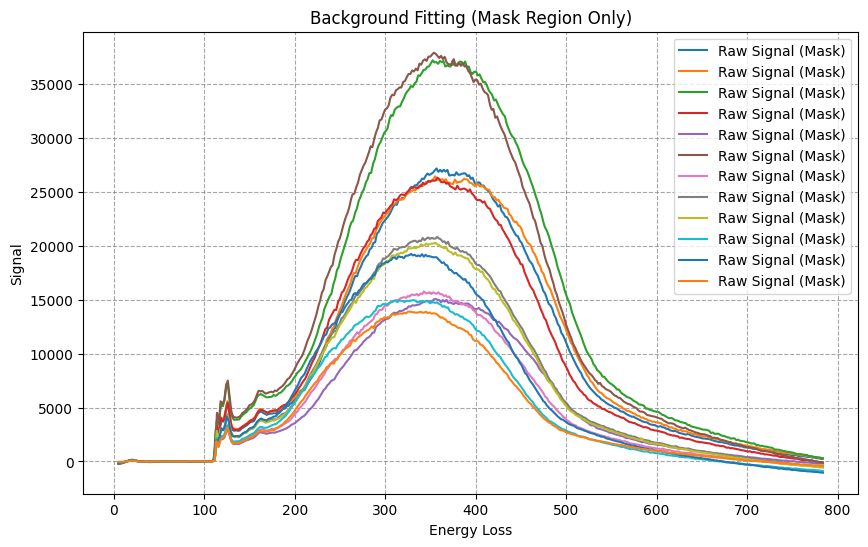

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [3]:
from xrsana import xrs_process

processor = xrs_process.XRSProcess(data, ["Ho"], [1], {"Ho": ["N4"]})
processor.xrs_remove_elastic()
processor.xrs_remove_stray_background()

plt.figure(figsize=(10, 6))
plt.plot(processor.eloss, processor.signals, label='Raw Signal (Mask)')


plt.title('Background Fitting (Mask Region Only)')
plt.xlabel('Energy Loss')
plt.ylabel('Signal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.show()

plt.figure(figsize=(10, 6))



column 1: scale = 2.2998127791740187e-10


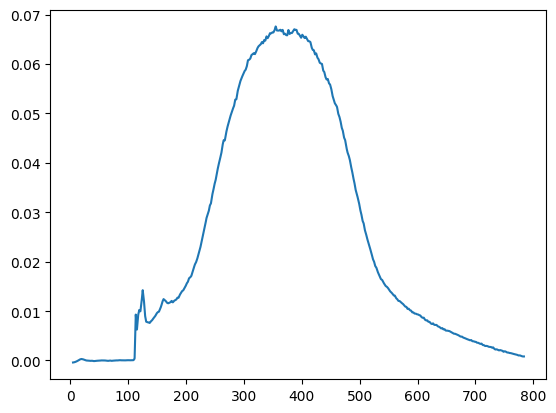

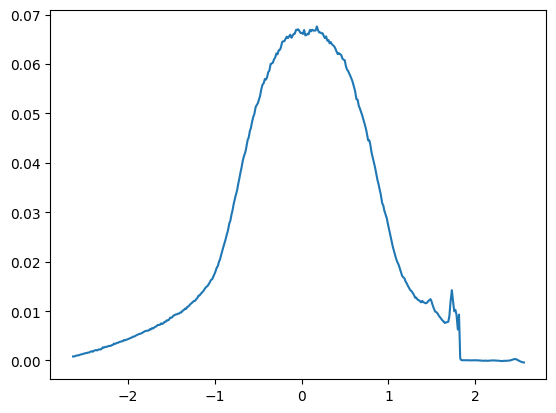

In [4]:
I0 = 1e13
sample_ro = 8.79
M = 164.93
sample_thickness = 0.1
pz = processor.xrs_energy_correction(0,8.79,sample_thickness,whichq=1)

plt.plot(processor.eloss,processor.signals[:,1])
plt.show()
plt.plot(pz,processor.signals[:,1])
plt.show()

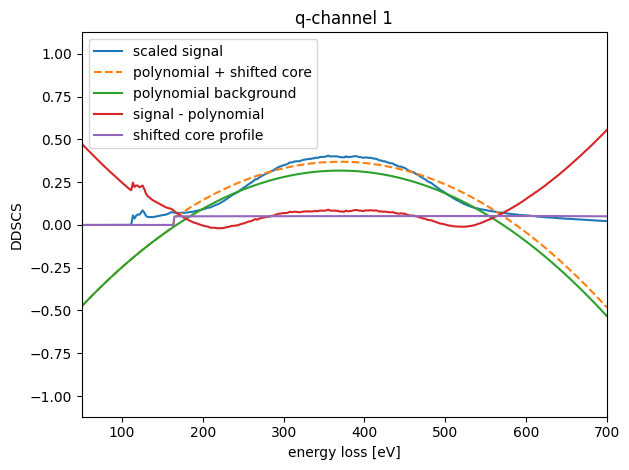

{1: {'coeffs': array([-7.78156668e-06,  5.74825831e-03, -7.43839459e-01]),
  'polyorder': 2,
  'scale': 6,
  'hfcoreshift': 0.0,
  'polyregion': (200, 600),
  'coreregion': (150, 170),
  'weights': (1.0, 1.0),
  'polynomial_background': array([-0.71529271, -0.71415893, -0.71302577, ..., -1.01632245,
         -1.01761154, -1.01890126], shape=(3895,)),
  'shifted_core': array([0.        , 0.        , 0.        , ..., 0.04697207, 0.04696108,
         0.04695008], shape=(3895,)),
  'corrected_spectrum': array([0.7128112 , 0.71168245, 0.71055433, ..., 1.02112218, 1.02242055,
         1.02371955], shape=(3895,)),
  'fit_cost': np.float64(3.8431398665312653),
  'fit_result':      message: Both `ftol` and `xtol` termination conditions are satisfied.
       success: True
        status: 4
           fun: [-5.416e-02 -5.434e-02 ...  1.134e-02  1.078e-02]
             x: [-7.782e-06  5.748e-03 -7.438e-01]
          cost: 1.9215699332656315
           jac: [[-4.000e+04 -2.000e+02 -1.000e+00]
     

In [5]:
processor.xrs_remove_poly_core(
        whichq = 1,
        polyregion = (200,600),
        coreregion = (150,170),
        weights=(1.0, 1.0),
        polyorder=2,
        scale=6,
        hfcoreshift=0.0,
        plot=True,
        ewindow=100.0,
        save_result=True,)

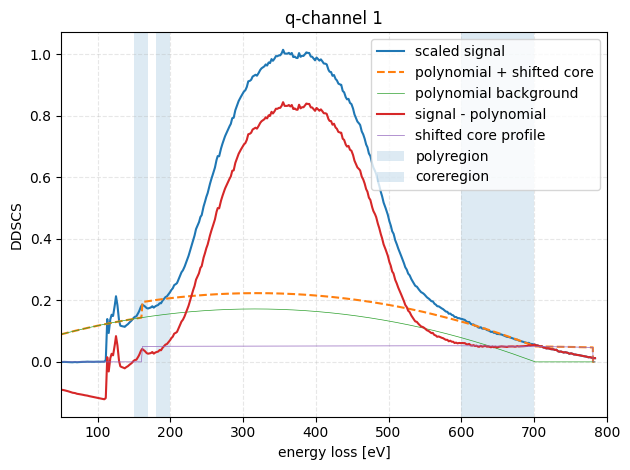

{1: {'coeffs': array([-1.16114134e-06,  7.34933828e-04,  5.56508547e-02]),
  'polyorder': 2,
  'scale': 15,
  'hfcoreshift': -3,
  'polyregion': [(180.0, 200.0), (600.0, 700.0)],
  'coreregion': (150.2, 170.0),
  'weights': (1.0, 1.0),
  'polynomial_background': array([0.0592965 , 0.05944111, 0.05958564, ..., 0.        , 0.        ,
         0.        ], shape=(3895,)),
  'shifted_core': array([0., 0., 0., ..., 0., 0., 0.], shape=(3895,)),
  'corrected_spectrum': array([-0.06550027, -0.06563231, -0.06576425, ...,  0.01199931,
          0.01202252,  0.01204573], shape=(3895,)),
  'fit_cost': np.float64(0.057506600458755636),
  'fit_result':      message: `xtol` termination condition is satisfied.
       success: True
        status: 3
           fun: [-1.958e-02 -1.940e-02 ... -2.364e-02 -2.356e-02]
             x: [-1.161e-06  7.349e-04  5.565e-02]
          cost: 0.028753300229377797
           jac: [[-3.240e+04 -1.800e+02 -1.000e+00]
                 [-3.247e+04 -1.802e+02 -1.000e+00

In [15]:
processor.xrs_remove_poly_core_2(
        whichq = 1,
        polyregion = [[180,200],[600,700]],
        coreregion = (150.2,170),
        weights=(1.0, 1.0),
        polyorder=2,
        scale=15,
        hfcoreshift=-3,
        plot=True,
        ewindow=100.0,
        save_result=True,)

In [33]:
processor.extractval(
    whichq=1,
    mirror=False,
    linrange1=(10, 20),
    linrange2=(80, 100),
    edge_pz=0.8,
    make_plots=True,
)

Trying to extract valence asymmetry.


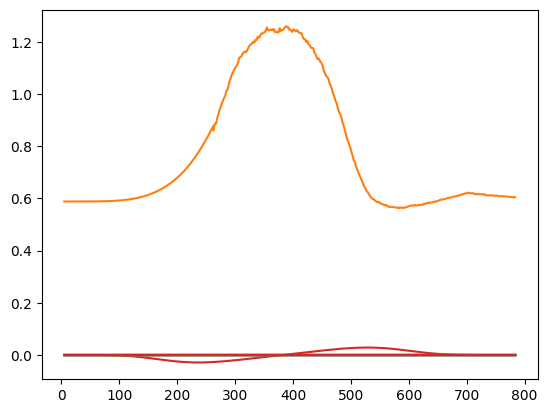

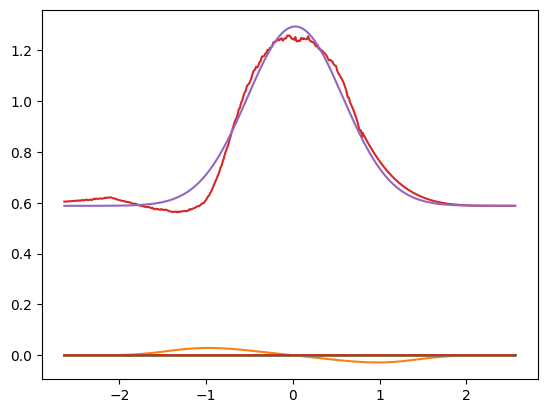

In [34]:
plt.plot(processor.eloss,processor.valence,label = "valence")
plt.plot(processor.eloss,processor.valasymmetry,label = "valasymmetry")
plt.show()
plt.plot(pz,processor.valasymmetrypz)
plt.plot(pz,processor.valencepz)
info = processor.pearson_info[1]
params = info["params"]   # [peak_pos, FWHM, shape, intensity, background]
edge   = info["edge"]     # boundary pz value
pearson = pearson7(pz, params)
plt.plot(pz, pearson)
plt.show()